# Does Film Genre Structure Collaboration Networks in the Cinema Industry?

This notebook investigates whether the genre of films shapes the way actors collaborate with one another, using an actor-actor co-occurrence network built from IMDb data, restricted to french movies from the last 15 years.

Each **node** is an actor. An **edge** connects two actors who appeared in at least one common film, with attributes capturing the genres of those shared films, their co-occurrence weight, and temporal information.

The analysis is structured around three main questions:
1. **Global structure** — what does the network look like overall?
2. **Genre from the actor's perspective** — do actors mainly collaborate within their own primary genre?
3. **Genre from the film's perspective** — do shared films cluster collaborations by genre?

## 1. Setup — Loading the Graph

Nodes and edges are loaded from CSV files exported from Gephi. Each node carries actor-level attributes (main genre, region, career span, etc.) and each edge carries collaboration-level attributes (shared films, main common genre, weight, etc.).

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import math
from collections import Counter
from matplotlib.lines import Line2D

# Load exported CSV files
nodes_df = pd.read_csv("../data/graph/gephi_nodes_acteurs.csv")
edges_df = pd.read_csv("../data/graph/gephi_edges_acteurs.csv")

# Build undirected graph
G = nx.Graph()

for _, row in nodes_df.iterrows():
    G.add_node(row["Id"], **row.drop("Id").dropna().to_dict())

for _, row in edges_df.iterrows():
    G.add_edge(row["Source"], row["Target"],
               **row.drop(["Source", "Target", "Type"]).dropna().to_dict())

## 2. Global Network Overview

Basic structural statistics of the full graph.

In [2]:
print(f"Nodes       : {G.number_of_nodes():,}")
print(f"Edges       : {G.number_of_edges():,}")
print(f"Density     : {nx.density(G):.6f}")
print(f"Self-loops  : {nx.number_of_selfloops(G)}")

Nodes       : 5,470
Edges       : 16,785
Density     : 0.001122
Self-loops  : 0


The graph contains **5,470 actors** and **16,785 collaboration edges**. The very low density (0.001) is expected for a co-occurrence network of this scale — most actors only collaborate within a small circle.

### 2.1 Connected Components

We check whether the graph is fully connected and examine the size distribution of connected components.

In [3]:
components = list(nx.connected_components(G))
sizes = sorted([len(c) for c in components], reverse=True)

print(f"Connected         : {nx.is_connected(G)}")
print(f"# Components      : {len(components)}")
print(f"Largest component : {sizes[0]} nodes ({sizes[0]/G.number_of_nodes()*100:.1f}% of the graph)")
print(f"Isolated nodes    : {sum(1 for s in sizes if s == 1)}")

# Extract the largest connected component for distance-based metrics
largest_cc = max(components, key=len)
G_cc = G.subgraph(largest_cc).copy()

Connected         : False
# Components      : 786
Largest component : 2006 nodes (36.7% of the graph)
Isolated nodes    : 252


The graph is **not fully connected** — it has 786 components. However, the largest component contains ~2,006 nodes (~37% of all actors), forming a dense collaborative core. The remaining components are mostly small isolated clusters or singletons.

### 2.2 Degree Distribution

In [4]:
degrees = dict(G.degree())
deg_values = list(degrees.values())

deg_df = pd.DataFrame(degrees.items(), columns=["node", "degree"]).sort_values("degree", ascending=False)

print(f"Average degree : {np.mean(deg_values):.2f}")
print(f"Max degree     : {np.max(deg_values)}")
print()
print("Top 10 most connected actors:")
print(deg_df.head(10).to_string(index=False))

Average degree : 6.14
Max degree     : 49

Top 10 most connected actors:
     node  degree
nm0491777      49
nm0243620      48
nm0099828      47
nm0856493      43
nm0714235      39
nm0749363      37
nm0075710      36
nm0531195      36
nm0419894      36
nm0705005      35


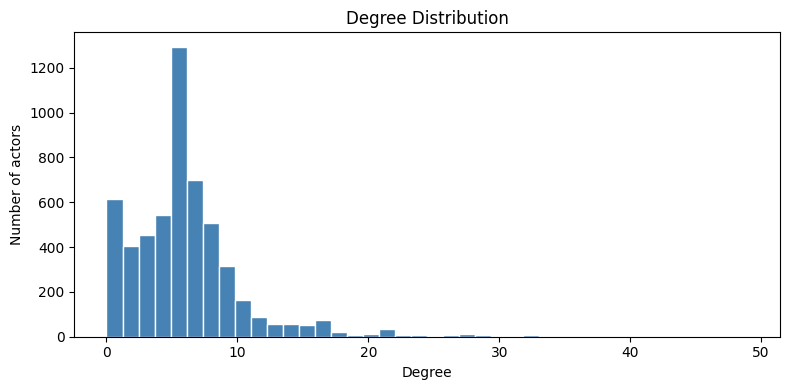

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(deg_values, bins=40, color="steelblue", edgecolor="white")
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of actors")
plt.tight_layout()
plt.show()

The degree distribution is heavily right-skewed: most actors have very few collaborators, while a small number of highly connected actors form the structural backbone of the network.

### 2.3 Distance and Small-World Properties

Computed on the largest connected component only, as distance metrics require a connected graph.

In [6]:
print(f"Diameter             : {nx.diameter(G_cc)}")
print(f"Radius               : {nx.radius(G_cc)}")
print(f"Average path length  : {nx.average_shortest_path_length(G_cc):.3f}")
print(f"Average clustering   : {nx.average_clustering(G):.3f}")
print(f"Transitivity         : {nx.transitivity(G):.3f}")

Diameter             : 18
Radius               : 9
Average path length  : 5.761
Average clustering   : 0.781
Transitivity         : 0.583


With an average path length of ~5.8 and a high clustering coefficient of 0.78, the network displays **small-world properties**: actors are globally reachable in few steps while remaining locally tightly clustered. The diameter of 18 indicates the existence of peripheral actors far from the core.

### 2.4 Centrality

Degree centrality measures how connected an actor is; betweenness centrality measures how often an actor lies on the shortest path between two others — i.e. their role as a structural bridge.

In [7]:
deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G)

centralities = pd.DataFrame({
    "node"        : list(G.nodes()),
    "degree"      : [deg_cent[n] for n in G.nodes()],
    "betweenness" : [bet_cent[n] for n in G.nodes()]
})

print("Top 20 actors by betweenness centrality:")
centralities.sort_values("betweenness", ascending=False).head(20)

Top 20 actors by betweenness centrality:


,node,degree,betweenness
4860,nm6327727,0.002560,0.012803
1007,nm0456268,0.002011,0.012788
2256,nm1257423,0.005120,0.012108
419,nm0134618,0.004023,0.009526
152,nm0008506,0.005120,0.008590
2793,nm1759640,0.002011,0.008057
3473,nm2858661,0.001646,0.007173
2923,nm1918862,0.002560,0.006922
4569,nm5282266,0.003657,0.006907
4705,nm5674436,0.001828,0.006665


Some actors with moderate degree centrality rank very high on betweenness — they act as **bridges** between otherwise disconnected communities, potentially across genre boundaries.

## 3. Genre from the Actor's Perspective (Node Attributes)

Each actor has a `main_genre` attribute reflecting the genre they appear in most frequently across their filmography. We ask: do actors tend to collaborate with others who share the same primary genre?

### 3.1 Distribution of Actors by Main Genre

In [9]:
node_genres = [
    data.get("main_genre")
    for _, data in G.nodes(data=True)
    if data.get("main_genre") is not None
]

genre_counts = Counter(node_genres)

print("Top 10 genres by number of actors:")
for genre, count in genre_counts.most_common(10):
    print(f"  {genre:<15} {count}")

Top 10 genres by number of actors:
  Drama           2035
  Comedy          1433
  Action          460
  Horror          251
  Documentary     232
  Crime           220
  Adventure       162
  Thriller        125
  Biography       96
  Romance         75


Drama and Comedy dominate the actor pool, followed at a distance by Action, Horror, and Documentary.

### 3.2 Genre Assortativity

Assortativity measures the tendency of nodes to connect with similar nodes. A coefficient of 1 means actors only collaborate within their own genre; 0 means genre is irrelevant to collaboration.

In [10]:
assortativity = nx.attribute_assortativity_coefficient(G, "main_genre")
print(f"Genre assortativity (node attribute): {assortativity:.4f}")

Genre assortativity (node attribute): 0.7271


The assortativity of **0.73** is remarkably high, indicating a strong tendency for actors to collaborate with others from the same primary genre. This is a first strong signal that genre structures the collaboration network.

### 3.3 Intra- vs. Inter-Genre Collaboration Weight

We sum the edge weights (number of shared films) separately for intra-genre pairs (same main genre) and inter-genre pairs.

In [11]:
intra_weight = 0
inter_weight = 0

for u, v, data in G.edges(data=True):
    genre_u = G.nodes[u].get("main_genre")
    genre_v = G.nodes[v].get("main_genre")
    if genre_u and genre_v:
        if genre_u == genre_v:
            intra_weight += data.get("weight", 1)
        else:
            inter_weight += data.get("weight", 1)

print(f"Intra-genre weight : {intra_weight:,}")
print(f"Inter-genre weight : {inter_weight:,}")
print(f"Intra/inter ratio  : {intra_weight / inter_weight:.2f}")

Intra-genre weight : 13,665
Inter-genre weight : 3,414
Intra/inter ratio  : 4.00


**4 out of 5 shared films involve actors with the same primary genre.** The intra/inter ratio of ~4 confirms that genre boundaries are real barriers to collaboration: actors overwhelmingly co-star with others who specialise in the same genre.

## 4. Genre from the Film's Perspective (Edge Attributes)

Each edge carries the attribute `main_common_genre`, the most frequent genre across all films shared by the two actors. We now ask: does the genre of shared films reveal further structure in the network?

### 4.1 Edge Distribution by Genre

In [12]:
edge_genres = [
    data.get("main_common_genre")
    for _, _, data in G.edges(data=True)
    if data.get("main_common_genre") is not None
]

genre_counts_edges = Counter(edge_genres)

print("Top 10 genres by number of collaboration edges:")
for genre, count in genre_counts_edges.most_common(10):
    print(f"  {genre:<15} {count}")

Top 10 genres by number of collaboration edges:
  Comedy          5685
  Drama           5483
  Action          1625
  Crime           768
  Horror          588
  Adventure       503
  Thriller        379
  Biography       273
  Documentary     258
  Romance         249


Comedy and Drama together account for the majority of collaboration edges, consistent with their dominance in the actor distribution. Action is a distant third.

### 4.2 Per-Actor Genre Entropy

For each actor, we compute the distribution of genres across their collaboration edges, then measure how diverse this distribution is using **normalised entropy**. 

The entropy is normalised against the full set of genres across the whole graph (not just the actor's own genres), so all actors are compared on the same scale — an actor connected only via Drama edges gets a low entropy regardless of how many Drama collaborators they have.

In [13]:
all_genres = list(set([
    data.get("main_common_genre")
    for _, _, data in G.edges(data=True)
    if data.get("main_common_genre") is not None
]))

def actor_edge_genre_distribution(G, actor):
    genres = [
        G[actor][neighbor]["main_common_genre"]
        for neighbor in G.neighbors(actor)
        if G[actor][neighbor].get("main_common_genre") is not None
    ]
    return Counter(genres)

def normalized_entropy(counter, all_genres):
    total = sum(counter.values())
    probs = [counter.get(g, 0) / total for g in all_genres]
    H = -sum(p * math.log(p) for p in probs if p > 0)
    Hmax = math.log(len(all_genres))
    return H / Hmax

entropies = []
for node in G.nodes():
    dist = actor_edge_genre_distribution(G, node)
    if len(dist) > 1:
        entropies.append(normalized_entropy(dist, all_genres))

print(f"Mean normalised entropy : {sum(entropies)/len(entropies):.4f}")
print(f"(0 = fully specialised, 1 = perfectly uniform across all genres)")

Mean normalised entropy : 0.2282
(0 = fully specialised, 1 = perfectly uniform across all genres)


The mean normalised entropy of **0.228** is low, confirming that most actors are **genre-specialist collaborators**: the films they make together with their co-stars overwhelmingly belong to a single genre. Genre specialisation is the norm, not the exception.

### 4.3 Community Purity by Genre

We detect communities using the Louvain algorithm and measure **genre purity** — the share of edges within each community that belong to the dominant genre. 

To assess whether the observed purity is higher than chance, we compare it to a **null model** where genre labels are randomly shuffled across edges.

In [14]:
import random

# ── Null model: shuffle genre labels ──────────────────────────────────────────
shuffled_genres = edge_genres.copy()
random.shuffle(shuffled_genres)

i = 0
for u, v, d in G.edges(data=True):
    if d.get("main_common_genre") is not None:
        d["random_genre"] = shuffled_genres[i]
        i += 1

# ── Community detection ───────────────────────────────────────────────────────
from networkx.algorithms.community import greedy_modularity_communities
communities = list(greedy_modularity_communities(G))

def community_purity_df(communities, genre_attr):
    rows = []
    for i, comm in enumerate(communities):
        sub_edges = [(u, v, d) for u, v, d in G.edges(data=True) if u in comm and v in comm]
        genres = [d.get(genre_attr) for _, _, d in sub_edges if d.get(genre_attr) is not None]
        if genres:
            counter = Counter(genres)
            total = sum(counter.values())
            main_genre, count = counter.most_common(1)[0]
            purity  = count / total
            entropy = normalized_entropy(counter, all_genres)
            rows.append((i, main_genre, purity, entropy, len(comm)))
    return pd.DataFrame(rows, columns=["community", "main_genre", "purity", "entropy", "size"])

df_real   = community_purity_df(communities, "main_common_genre")
df_random = community_purity_df(communities, "random_genre")

print("=== Real genre labels ===")
print(df_real.loc[df_real.groupby("main_genre")["size"].idxmax()]
      .sort_values("size", ascending=False)
      .to_string(index=False))

print()
print("=== Shuffled genre labels (null model) ===")
print(df_random.loc[df_random.groupby("main_genre")["size"].idxmax()]
      .sort_values("size", ascending=False)
      .to_string(index=False))

=== Real genre labels ===
 community  main_genre   purity   entropy  size
         0      Comedy 0.583477  0.461176  1046
         1       Drama 0.460157  0.490653   232
         6      Action 0.351097  0.587686    79
        17       Crime 0.500000  0.325234    26
        18      Horror 0.481013  0.409745    26
        23   Adventure 0.439024  0.326936    21
        29     Musical 0.424242  0.338299    19
        31    Thriller 0.616438  0.222243    18
        39       Adult 1.000000 -0.000000    15
        68   Biography 1.000000 -0.000000    10
        72     Fantasy 1.000000 -0.000000     9
       107     Romance 1.000000 -0.000000     8
       129 Documentary 1.000000 -0.000000     7
       179   Animation 1.000000 -0.000000     6
       185      Sci-Fi 1.000000 -0.000000     6
       167     Mystery 1.000000 -0.000000     6
       217      Family 1.000000 -0.000000     5
       374         War 1.000000 -0.000000     3
       471     History 1.000000 -0.000000     2
       444    

Comparing real vs. shuffled labels: the **purity of the largest communities drops significantly** under the null model (e.g. Comedy community: 0.58 → 0.35), confirming that the moderated genre coherence observed within communities is not a statistical artefact — genre is an organizing factor of the community structure of the network.

## 5. Network Visualisations

### 5.1 Six Largest Communities — Edges Coloured by Genre

We plot the 6 largest communities detected by Louvain, with each edge coloured by its `main_common_genre`. A shared colour legend makes genre patterns comparable across communities.

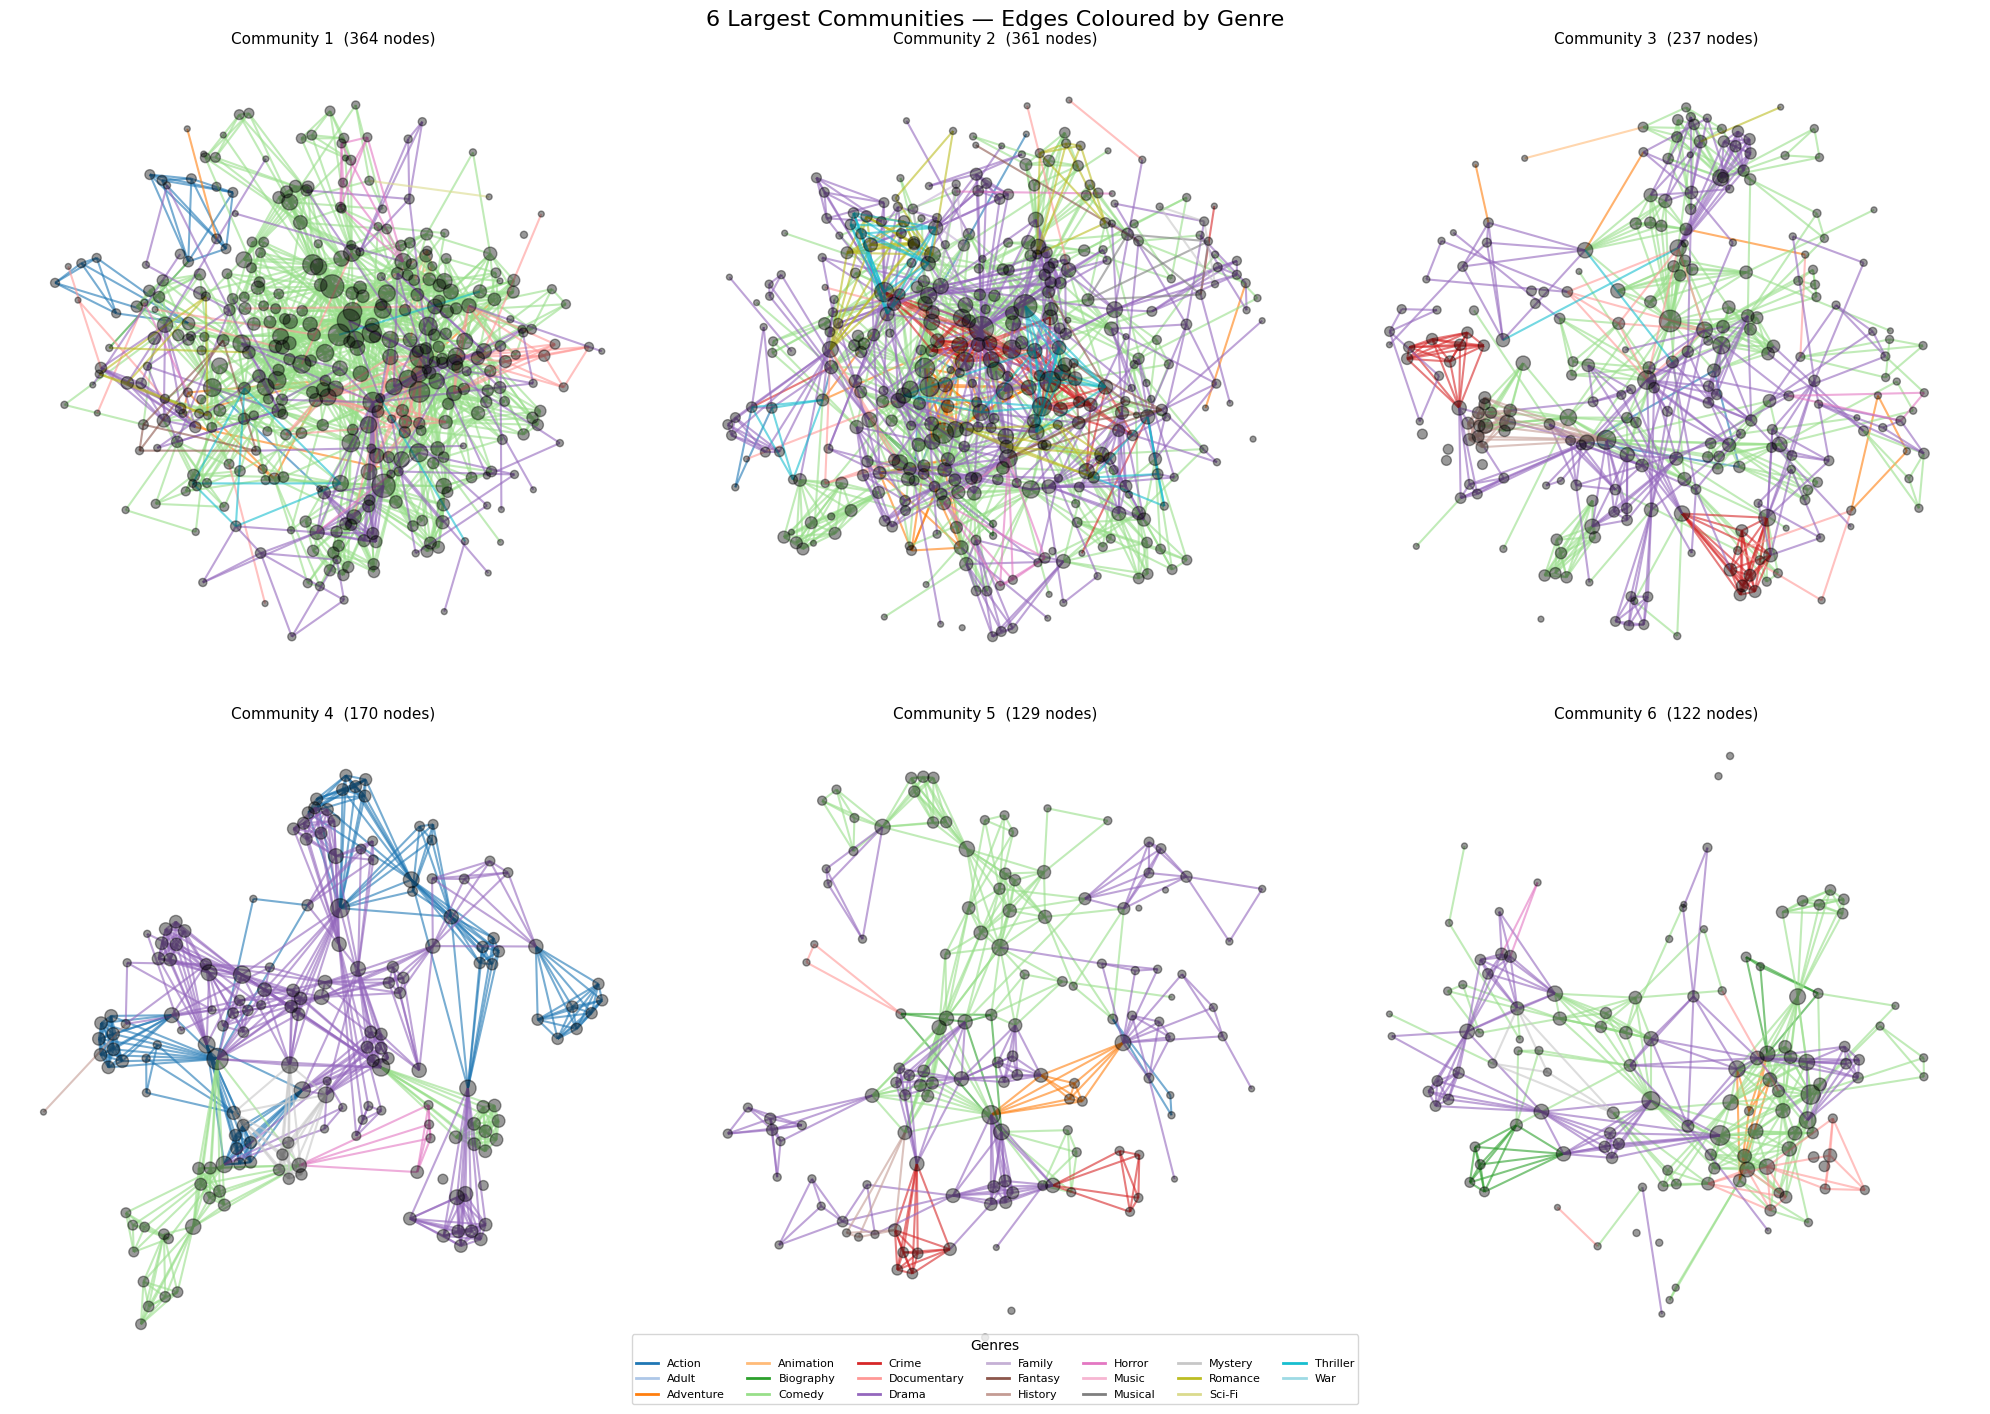

In [15]:
H = G.copy()
communities_louvain = nx.community.louvain_communities(H, seed=42)
communities_louvain = sorted(communities_louvain, key=len, reverse=True)[:6]

genres_list = sorted(set([
    data.get("main_common_genre")
    for _, _, data in H.edges(data=True)
    if data.get("main_common_genre") is not None
]))

cmap = plt.cm.tab20
color_map = {g: cmap(i % 20) for i, g in enumerate(genres_list)}

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for idx, community in enumerate(communities_louvain):
    ax = axes[idx]
    subgraph = H.subgraph(community).copy()
    pos = nx.spring_layout(subgraph, k=0.3, iterations=50, seed=42)

    degrees_sub = dict(subgraph.degree())
    node_sizes  = [10 + degrees_sub[n] * 8 for n in subgraph.nodes()]

    nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes,
                           node_color="black", alpha=0.4, ax=ax)

    for genre in genres_list:
        edges = [(u, v) for u, v, d in subgraph.edges(data=True)
                 if d.get("main_common_genre") == genre]
        if not edges:
            continue
        nx.draw_networkx_edges(subgraph, pos, edgelist=edges,
                               edge_color=[color_map[genre]],
                               width=1.5, alpha=0.6, ax=ax)

    ax.set_title(f"Community {idx + 1}  ({len(community)} nodes)", fontsize=11)
    ax.axis("off")

legend_handles = [Line2D([0], [0], color=color_map[g], linewidth=2, label=g)
                  for g in genres_list]
fig.legend(handles=legend_handles, loc="lower center", ncol=7,
           fontsize=8, title="Genres", title_fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle("6 Largest Communities — Edges Coloured by Genre", fontsize=16)
plt.tight_layout()
plt.show()

### 5.2 Genre Subgraphs — Structural Indicators

For each genre, we extract the induced subgraph of edges labelled with that genre and plot it with a set of cohesion indicators. Node size is proportional to degree within the subgraph.

**Indicators:**
- **Clustering** — average local clustering coefficient (size-independent)  
- **Transitivity** — global ratio of closed triangles (weights hubs more)  
- **Components** — number of disconnected fragments  
- **Avg. degree** — mean number of connections per actor within this genre subgraph

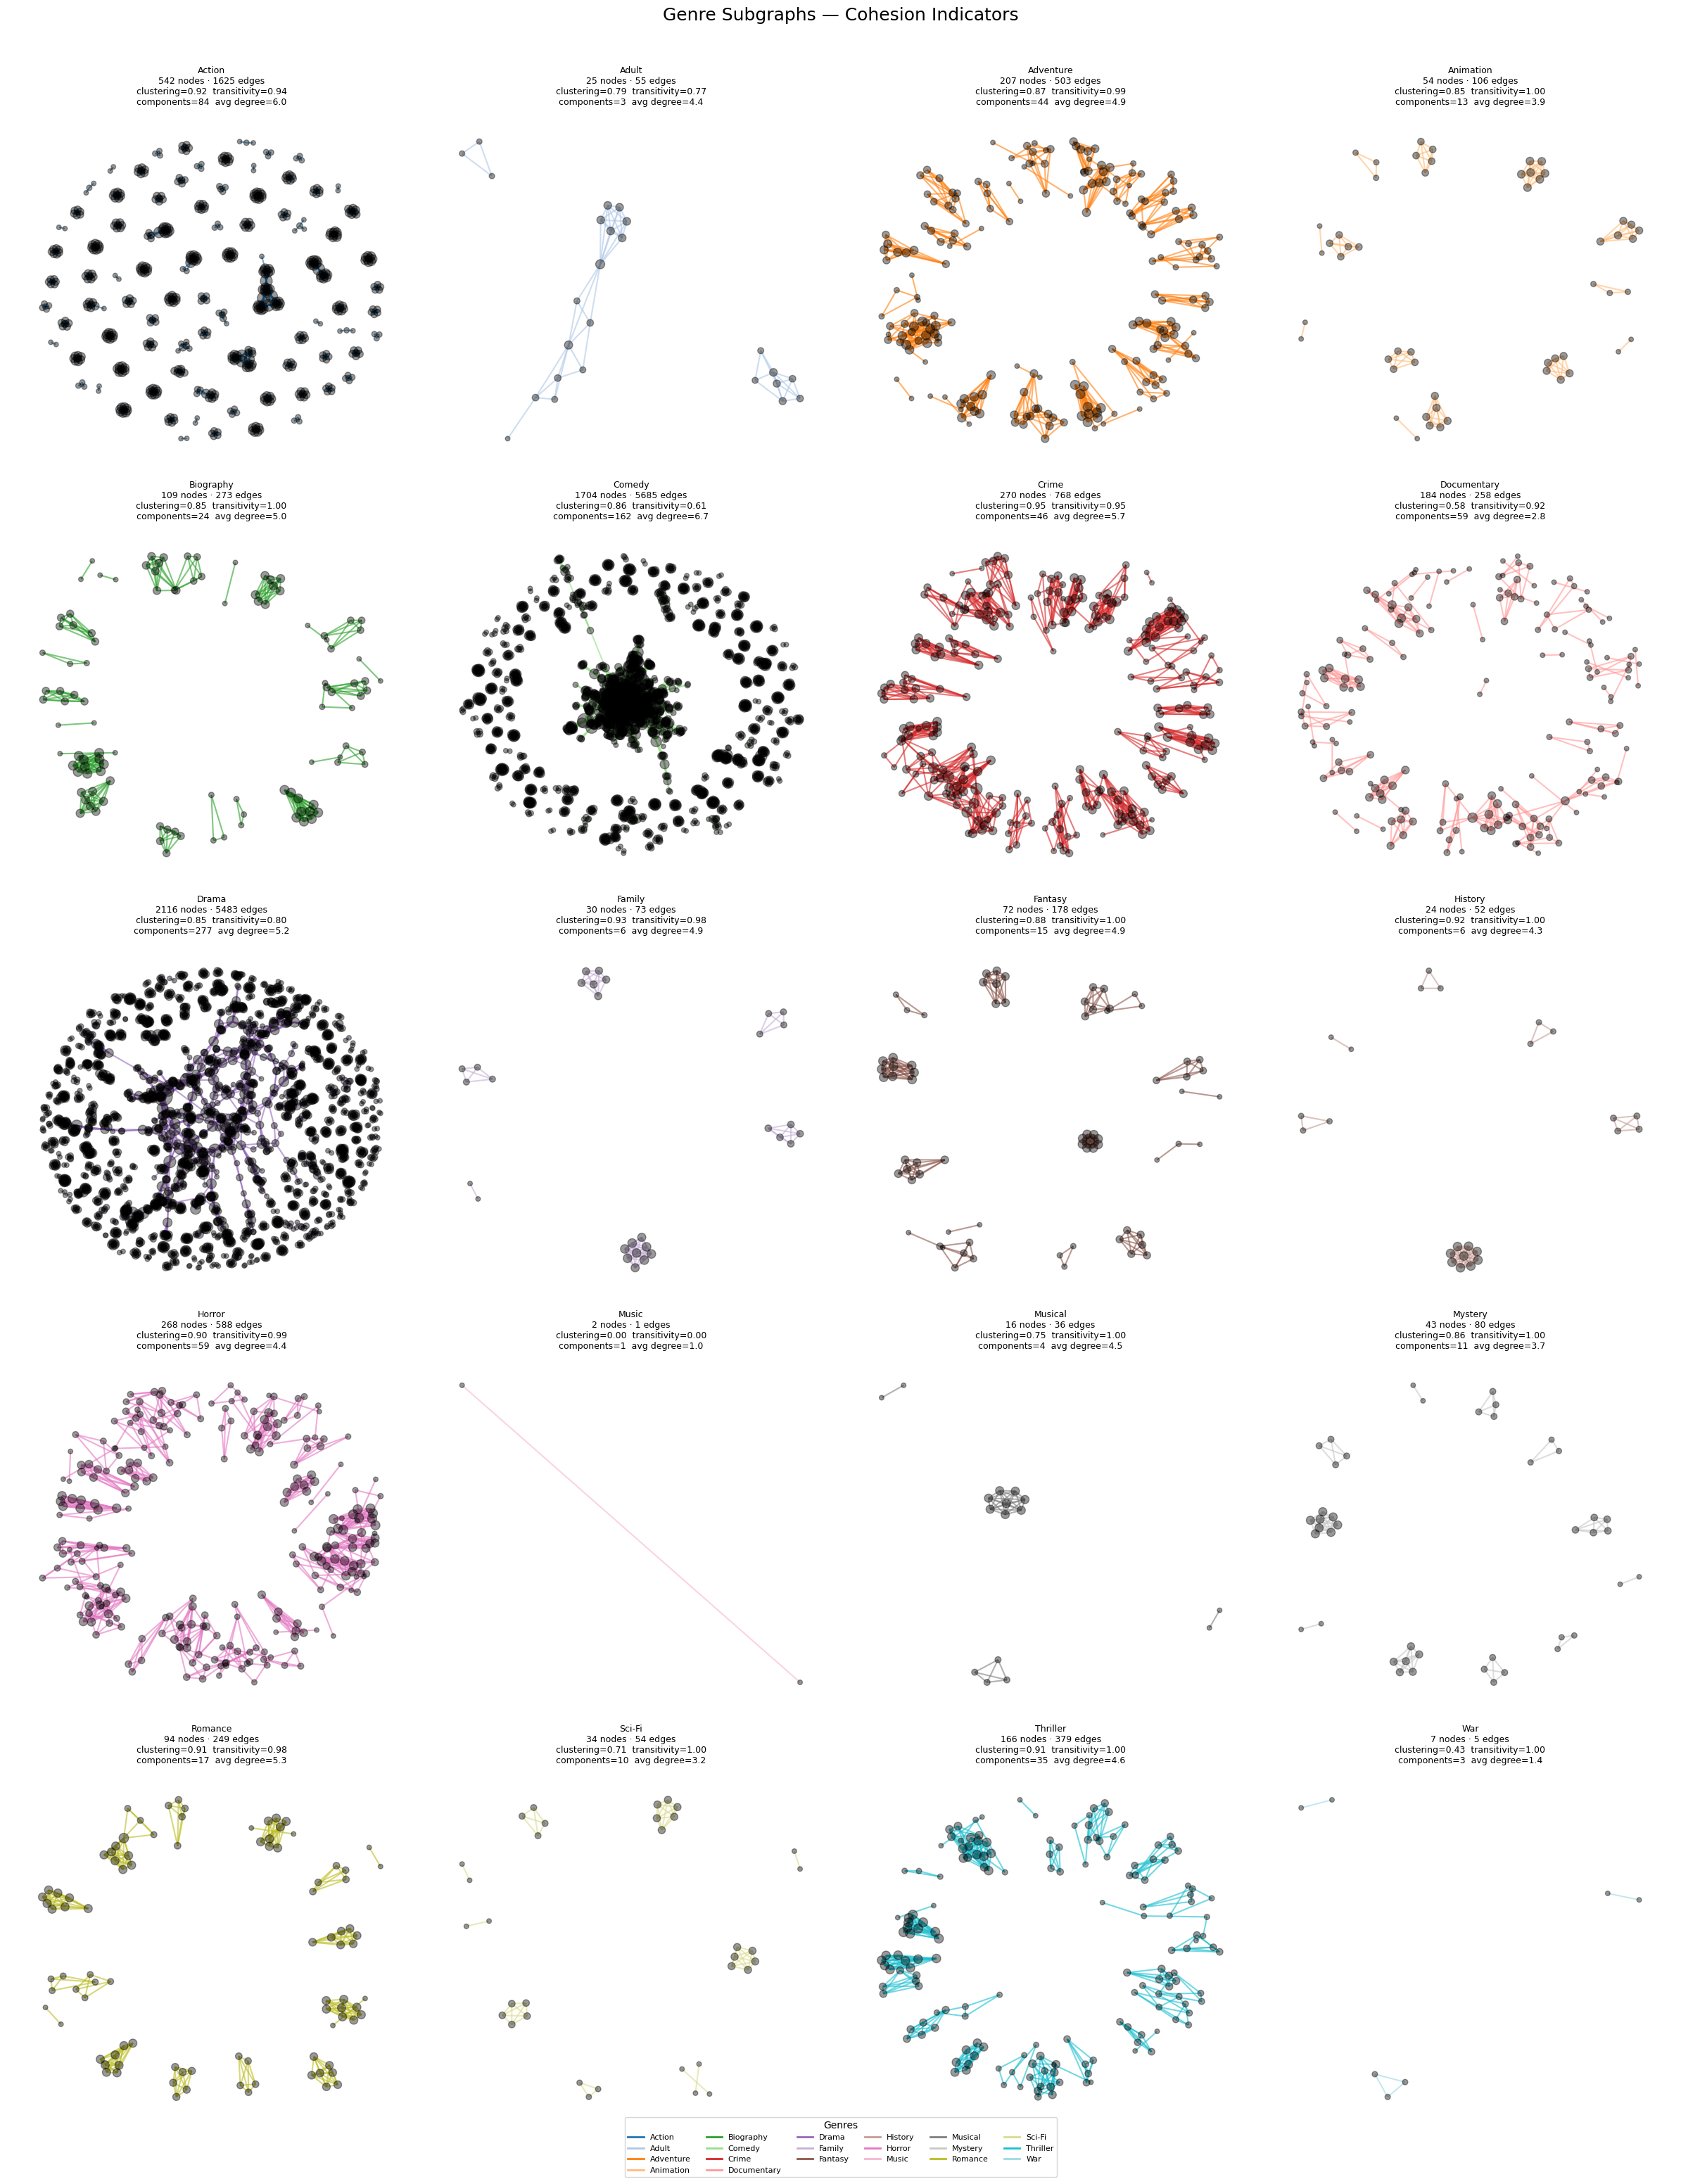

In [16]:
def subgraph_by_genre(G, genre):
    edges = [(u, v, d) for u, v, d in G.edges(data=True)
             if d.get("main_common_genre") == genre]
    H = nx.Graph()
    H.add_edges_from(edges)
    for n in H.nodes():
        H.nodes[n].update(G.nodes[n])
    return H

genres_sorted = sorted(genres_list)
ncols = 4
nrows = (len(genres_sorted) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(24, nrows * 6))
axes = axes.flatten()

for idx, genre in enumerate(genres_sorted):
    ax = axes[idx]
    sg = subgraph_by_genre(G, genre)

    if sg.number_of_nodes() == 0:
        ax.axis("off")
        continue

    pos = nx.spring_layout(sg, k=0.3, iterations=50, seed=42)
    deg = dict(sg.degree())
    node_sizes = [15 + deg[n] * 8 for n in sg.nodes()]

    nx.draw_networkx_nodes(sg, pos, node_size=node_sizes,
                           node_color="black", alpha=0.4, ax=ax)
    nx.draw_networkx_edges(sg, pos, edge_color=color_map[genre],
                           width=1.5, alpha=0.6, ax=ax)

    clustering    = nx.average_clustering(sg)
    transitivity  = nx.transitivity(sg)
    n_comp        = nx.number_connected_components(sg)
    avg_deg       = sum(d for _, d in sg.degree()) / sg.number_of_nodes()

    ax.set_title(
        f"{genre}\n{sg.number_of_nodes()} nodes · {sg.number_of_edges()} edges\n"
        f"clustering={clustering:.2f}  transitivity={transitivity:.2f}\n"
        f"components={n_comp}  avg degree={avg_deg:.1f}",
        fontsize=9
    )
    ax.axis("off")

for idx in range(len(genres_sorted), len(axes)):
    axes[idx].axis("off")

legend_handles = [Line2D([0], [0], color=color_map[g], linewidth=2, label=g)
                  for g in genres_sorted]
fig.legend(handles=legend_handles, loc="lower center", ncol=6,
           fontsize=8, title="Genres", title_fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Genre Subgraphs — Cohesion Indicators", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

## 6. Summary

The analysis converges on a nuanced but clear answer to the research question:

**Genre is a important factor in the collaboration structure of the cinema industry**, and this holds across all levels of analysis:

| Dimension | Evidence | Value |
|---|---|---|
| Actor specialisation | Genre assortativity (node) | 0.73 |
| Co-star specialisation | Intra/inter genre weight ratio | 4.0× |
| Collaboration diversity | Mean normalised entropy | 0.23 |
| Community coherence | Purity (real vs. shuffled) | 0.58 vs. 0.35 |

Genre acts as a **structural organising principle** of the network: actors tend to work within genre-specific communities, the films they share are dominated by a single genre, and their collaboration networks fragment clusters with specific genre domination. Cross-genre bridges exist but are rare, and the actors who occupy them play a disproportionate structural role (high betweenness centrality relative to their degree).